# Trasformazione della Liquidità: perché un ETF può essere liquido anche se detiene asset illiquidi

**Corso:** Advanced Fixed Income and Credit — Analisi al contorno
**Tema:** *Market microstructure insights*

## Domanda di ricerca

> **Se l'ETF ha un sottostante illiquido, come fa ad essere liquido esso stesso?**

## Dove si inserisce questa analisi

L'analisi principale risponde a questa domanda descrivendo il meccanismo
istituzionale nei suoi due livelli:

1. **Mercato secondario** (order-driven) — gli investitori scambiano quote
   dell'ETF fra loro; i market maker forniscono liquidità in modo continuo,
   quotando bid/ask, e si coprono dal rischio di inventario tramite
   **continuous hedging** (strumenti liquidi correlati, non le singole
   obbligazioni sottostanti a ogni trade).
2. **Mercato primario** — quando l'inventario del market maker si sbilancia
   troppo, gli Authorized Participants (AP) lo riassorbono tramite il
   meccanismo di **creation/redemption**, l'unico punto in cui la domanda o
   offerta netta di quote ETF tocca davvero le obbligazioni sottostanti.

Questo notebook **non sostituisce** quella descrizione — la completa da un
angolo diverso, puramente statistico: invece di descrivere *il meccanismo*
(hedging, creation/redemption), ne misuriamo **l'impronta nei dati di
prezzo**. Se il racconto istituzionale è corretto, deve lasciare una traccia
osservabile: il prezzo dell'ETF (guidato dal trading continuo e dall'hedging
del market maker sul secondario) dovrebbe comportarsi da processo "fresco",
mentre il NAV (che dipende dalla valutazione, spesso non sincrona, delle
singole obbligazioni) dovrebbe comportarsi da processo "stantio". Questo è
esattamente ciò che testiamo.

## Come si legge il notebook

Ogni blocco tecnico (un modello, una proposizione, una simulazione) è
seguito da un paragrafo **"In parole semplici"** che lo riformula senza
formule — pensato per essere riusato tale e quale nell'esposizione orale.

## Pipeline

Analisi puramente econometrica: due modelli statistici, due stimatori (uno
puntuale, uno un test di ipotesi formale), validati su dati sintetici e poi
applicati a dati reali. Nessuna classificazione a regimi (HMM) — quella resta
nel progetto principale, applicata al premio/sconto.

1. **I due modelli di partenza** — fissiamo esplicitamente, prima di
   misurare qualunque cosa, il modello statistico per il NAV e quello per il
   prezzo dell'ETF, motivandoli con il racconto istituzionale sopra
2. **Stimatori** — autocorrelazione rolling di ordine 1, variance ratio
   (Lo–MacKinlay, 1988), e il test di Ljung–Box (significatività formale
   dell'autocorrelazione)
3. **Validazione sintetica** — verifichiamo che gli stimatori recuperino
   correttamente i parametri noti dei due modelli, e che il test rifiuti/non
   rifiuti l'ipotesi nulla come atteso
4. **Diagnostica rolling** — le stime seguono un parametro che cambia nel
   tempo, su un percorso sintetico con regime noto
5. **Dati reali** — NAV storico di LQD e HYG (nessuna rete richiesta);
   confronto cross-fondo (ipotesi: high-yield più stantio di investment-grade)
6. **Estensione a rete** — confronto completo NAV-vs-prezzo su dati reali,
   da eseguire in locale con `DEMO = False`

### Librerie e configurazione grafica

In [1]:
%matplotlib inline
from __future__ import annotations

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)

# If running in Colab and a package is missing, uncomment:
# !pip install yfinance --quiet

os.makedirs("../figures", exist_ok=True)  # figures below are saved here (sibling folder)

np.random.seed(7)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Configurazione

In [2]:
# ============================================================================
# CONFIGURATION - edit here to switch between demo and real data
# ============================================================================
DEMO = True              # True = synthetic data only (no network needed)
TICKERS = ["LQD", "HYG"]  # real-data tickers, used only when DEMO = False
NAV_CSV = {               # local NAV history files already parsed from iShares exports
    "LQD": "../data/lqd_nav_history.csv",
    "HYG": "../data/hyg_nav_history.csv",
}

ROLL_WINDOW = 60          # trading days, rolling window for autocorrelation / VR
VR_HORIZON = 5            # q in the Lo-MacKinlay variance ratio VR(q)
LB_LAGS = 10              # number of lags tested jointly by the Ljung-Box test
RANDOM_SEED = 7

## 2. I due modelli di partenza

Prima di stimare o simulare qualunque cosa, fissiamo esplicitamente **due
modelli statistici distinti** — uno per il rendimento riportato nel NAV, uno
per il rendimento di prezzo dell'ETF — motivati direttamente dal racconto
istituzionale a due livelli dell'analisi principale. Sia $r^\ast_t$ il
rendimento "vero" (economico, non osservabile) del paniere di obbligazioni
al giorno $t$: entrambi i modelli sotto sono scritti in funzione di
$r^\ast_t$, ma lo "vedono" in modo diverso.

### 2.1 Modello del NAV: valutazione stantia (Getmansky–Lo–Makarov, 2004)

Il NAV è calcolato dall'amministratore del fondo sommando i prezzi delle
singole obbligazioni nel paniere — il lato **primario/di valutazione** del
mercato. Molte obbligazioni non scambiano ogni giorno: quando non lo fanno,
il pricing desk usa un matrix price basato sull'ultimo prezzo osservato.
Il rendimento **riportato** nel NAV non è quindi $r^\ast_t$, ma una media
pesata dei rendimenti veri recenti,
$$
r^{NAV}_t = \sum_{j=0}^{k-1} \theta_j  r^\ast_{t-j}, \qquad \theta_j \ge 0,\quad \sum_{j=0}^{k-1}\theta_j = 1.
$$
Useremo pesi a decadimento geometrico, $\theta_j = (1-\phi)\phi^{j}$, con
$\phi\in[0,1)$ il **parametro di smoothing/staleness** ($\phi=0$: nessuno
smoothing; $\phi\to 1$: smoothing molto persistente).

**Perché genera autocorrelazione: un esempio minimo.** Caso più semplice,
metà peso su oggi, metà su ieri: $r^{NAV}_t = 0.5 r^\ast_t + 0.5 r^\ast_{t-1}$.
Con rendimenti veri (indipendenti) nei giorni 1–4 pari a $+2\%,-1\%,+3\%,+1\%$:
\begin{align*}
r^{NAV}_2 &= 0.5(-1\%)+0.5(2\%) = 0.5\%, \\
r^{NAV}_3 &= 0.5(3\%)+0.5(-1\%) = 1.0\%, \\
r^{NAV}_4 &= 0.5(1\%)+0.5(3\%) = 2.0\%.
\end{align*}
$r^{NAV}_3$ e $r^{NAV}_4$ condividono lo stesso ingrediente — lo shock
$+3\%$ del giorno 3, una volta come "oggi", di nuovo come "ieri" il giorno
dopo. Quello shock non è consumato in un colpo solo: metà finisce nel NAV di
oggi, l'altra metà trascina in alto anche quello di domani. È questa
sovrapposizione di ingredienti fra osservazioni consecutive a generare
autocorrelazione positiva.

**Risultato chiave.** Nel limite $k\to\infty$, $r^{NAV}_t$ è $MA(\infty)$ con
$\gamma(h) = \sigma^2\sum_j\theta_j\theta_{j+h}$; per i pesi geometrici,
$$
\gamma(h) = \sigma^2 \frac{(1-\phi)^2}{1-\phi^2} \phi^{h}
\quad\Longrightarrow\quad
\rho_1 := \frac{\gamma(1)}{\gamma(0)} = \phi.
$$
L'autocorrelazione di ordine 1 del NAV è **esattamente** $\phi$ — un'identità
esatta nel modello, non un'analogia.

> **In parole semplici.** Il NAV non "sa" subito quanto vale davvero il
> paniere di obbligazioni oggi, perché molte di esse non hanno scambiato:
> usa ancora un prezzo vecchio. L'informazione vera arriva quindi spalmata
> su più giorni invece che tutta insieme — e questo fa sì che un giorno
> "buono" per il NAV tenda a essere seguito da un altro giorno anch'esso un
> po' "buono", anche se economicamente lo shock era uno solo. Più
> obbligazioni sono illiquide (più $\phi$ è alto), più questo effetto dura
> nel tempo.

### 2.2 Modello del prezzo ETF: mercato secondario e hedging del market maker

Il prezzo dell'ETF si forma sul mercato secondario, order-driven, dove la
maggior parte degli scambi avviene **fra investitori tramite il market
maker**, senza mai toccare le obbligazioni sottostanti. Il market maker
fornisce liquidità continuamente e copre il rischio di inventario che ne
deriva con **continuous hedging** — tipicamente con strumenti liquidi
correlati (future su tassi, indici di credito), non ribilanciando il paniere
di obbligazioni a ogni singolo trade. Solo quando lo sbilancio di inventario
diventa troppo grande interviene il meccanismo di **creation/redemption**
con un AP, che è il punto di contatto con il mercato primario.

Modelliamo quindi il rendimento di prezzo come il rendimento vero più un
rumore idiosincratico i.i.d., che rappresenta il continuous hedging e il
rumore di microstruttura del secondario:
$$
r^{P}_t = r^\ast_t + \eta_t, \qquad \eta_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_\eta^2),\ \ \eta_t \perp r^\ast_s\ \ \forall s.
$$
Essendo somma di due processi i.i.d. indipendenti, $r^P_t$ è esso stesso
i.i.d.: $\rho_1(r^P) = 0$ in popolazione, per costruzione.

> **In parole semplici.** Il prezzo dell'ETF non ha bisogno di aspettare che
> le obbligazioni si riprezzino per aggiornarsi: il market maker lo tiene
> allineato al valore vero tramite il proprio hedging continuo su strumenti
> liquidi, giorno per giorno. Il nostro modello dice: il prezzo dell'ETF
> segue quasi esattamente il valore vero, più un po' di rumore che non
> lascia "memoria" da un giorno all'altro — l'opposto esatto del NAV.

**Un'asimmetria onesta da segnalare.** In questa forma il modello del
prezzo ETF è un caso "pulito" — un benchmark di prezzo efficiente. Il
classico modello di bid-ask bounce (Roll, 1984) implicherebbe in realtà una
lieve autocorrelazione *negativa*, non nulla. Non l'abbiamo inclusa per
tenere il modello di controllo semplice ($\rho_1$ teorico esattamente $0$);
è un'estensione naturale se si vuole un benchmark più realistico.

### 2.3 Variance ratio: diagnostica complementare

$$
VR(q) = \frac{\mathrm{Var}\left(\sum_{i=0}^{q-1} r_{t-i}\right)}{q \mathrm{Var}(r_t)}.
$$
Vale $1$ sotto rendimenti i.i.d. (il nostro modello di prezzo ETF) e cresce
con $\phi$ per il modello di NAV geometrico sopra (autocovarianza che decade
come $\phi^h$, come un $AR(1)$).

> **In parole semplici.** È un secondo modo di misurare la stessa cosa
> dell'autocorrelazione, ma guardando a un orizzonte di più giorni invece
> che solo a "ieri contro oggi" — utile come controllo di robustezza, non
> come sostituto di $\hat\rho_1$.

### 2.4 Riepilogo dei due modelli

| | Chi lo genera | Livello di mercato | $\rho_1$ atteso |
|---|---|---|---|
| $r^{NAV}_t$ | Valutazione (matrix pricing) delle obbligazioni | Primario / valutazione | $= \phi > 0$ |
| $r^{P}_t$ | Trading continuo + hedging del market maker | Secondario / order-driven | $\approx 0$ |

Il divario fra questi due valori attesi — misurabile senza mai vedere
l'order book delle obbligazioni — è la prova statistica diretta che
risponde alla domanda di ricerca: l'ETF è liquido perché il suo prezzo vive
prevalentemente nel processo "secondario" pulito, non in quello
"primario/di valutazione" stantio a cui è comunque ancorato (dal meccanismo
di creation/redemption, oggetto dell'analisi principale).

## 3. Stimatori e simulazione dei due modelli

Implementiamo i due modelli della Sezione 2 e tre strumenti per
distinguerli nei dati: autocorrelazione rolling di ordine 1, variance ratio,
e il **test di Ljung–Box**, che aggiunge una significatività formale a ciò
che $\hat\rho_1$ misura soltanto in modo puntuale.

### Il test di Ljung–Box

$\hat\rho_1$ è una stima — un numero soggetto a rumore campionario. Il test
di Ljung–Box chiede: è quel numero (o più in generale l'autocorrelazione
fino a un certo numero di lag) **statisticamente distinguibile da zero**, o
potrebbe essere solo rumore? L'ipotesi nulla è $H_0:\ \rho_1=\rho_2=\dots=\rho_L=0$
(nessuna autocorrelazione fino al lag $L$). La statistica test è
$$
Q = n(n+2)\sum_{k=1}^{L}\frac{\hat\rho_k^2}{n-k},
$$
che sotto $H_0$ è approssimativamente distribuita come un $\chi^2$ con $L$
gradi di libertà. Un $p$-value piccolo (convenzionalmente $<0.05$) rigetta
$H_0$: l'autocorrelazione osservata è troppo grande per essere spiegata dal
solo rumore campionario.

> **In parole semplici.** $\hat\rho_1$ ti dice *quanto* sembra esserci
> autocorrelazione; Ljung–Box ti dice se puoi *fidarti* di quel numero — se
> è abbastanza forte da non essere spiegabile per puro caso, dato quanti
> giorni di dati hai.

In [3]:
def make_geometric_weights(phi: float, k: int) -> np.ndarray:
    """Geometric smoothing weights theta_j = (1-phi) phi^j, renormalized to
    sum to 1 (correction for the finite-k truncation of the theoretically
    infinite MA(infinity) process). This implements the NAV model of
    Section 2.1."""
    j = np.arange(k)
    theta = (1.0 - phi) * phi**j
    theta = theta / theta.sum()
    return theta


def simulate_smoothed_fund(n: int, phi: float, k: int = 20, sigma: float = 1.0,
                            noise_ratio: float = 0.15, seed: int | None = None):
    """Simulate a fund's 'true' latent return, its smoothed/stale NAV return
    (Section 2.1 model), and its ETF market-price return (Section 2.2 model).

    Parameters
    ----------
    n : number of trading days to simulate
    phi : smoothing/staleness parameter in [0, 1); theoretical rho_1(NAV) = phi
    k : number of MA lags used for the (truncated) smoothing filter
    sigma : std dev of the true daily return
    noise_ratio : std dev of ETF idiosyncratic noise, as a fraction of sigma
    """
    rng = np.random.default_rng(seed)
    burn_in = k  # extra warm-up so the smoothing filter is fully "spun up"
    true_r = rng.normal(0.0, sigma, size=n + burn_in)

    theta = make_geometric_weights(phi, k)
    # NAV model (Sec. 2.1): obs[t] = sum_j theta_j * true_r[t-j]  <=>  causal convolution
    nav_r_full = np.convolve(true_r, theta, mode="full")[: len(true_r)]

    # ETF price model (Sec. 2.2): true return + i.i.d. idiosyncratic noise
    eta = rng.normal(0.0, sigma * noise_ratio, size=n + burn_in)
    etf_r_full = true_r + eta

    # drop the warm-up so the smoothing filter has "seen" k true lags everywhere
    true_r = true_r[burn_in:]
    nav_r = nav_r_full[burn_in:]
    etf_r = etf_r_full[burn_in:]
    return true_r, nav_r, etf_r


def rolling_autocorr_lag1(returns: pd.Series, window: int) -> pd.Series:
    """Rolling sample lag-1 autocorrelation, computed with pandas' own
    Series.autocorr (no statsmodels dependency)."""
    r = pd.Series(returns)
    return r.rolling(window).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)


def rolling_variance_ratio(returns: pd.Series, window: int, q: int) -> pd.Series:
    """Lo-MacKinlay variance ratio VR(q), computed on a trailing rolling
    window of daily returns."""
    r = pd.Series(returns)  # keep the original index so this aligns with rolling_autocorr_lag1

    def _vr(x):
        x = pd.Series(x)
        var_1 = x.var(ddof=1)
        if var_1 == 0 or len(x) <= q:
            return np.nan
        q_returns = x.rolling(q).sum().dropna()
        var_q = q_returns.var(ddof=1)
        return var_q / (q * var_1)

    return r.rolling(window).apply(_vr, raw=False)


def ljung_box_test(returns: pd.Series, lags: int) -> tuple[float, float]:
    """Ljung-Box Q-statistic and p-value, testing H0: no autocorrelation up
    to the given number of lags. Implemented directly (no statsmodels
    dependency): Q = n(n+2) * sum_{k=1}^{lags} rho_hat(k)^2 / (n-k), which is
    asymptotically chi-squared(lags) under H0."""
    r = pd.Series(returns).dropna()
    n = len(r)
    q_stat = 0.0
    for k in range(1, lags + 1):
        rho_k = r.autocorr(lag=k)
        q_stat += rho_k**2 / (n - k)
    q_stat *= n * (n + 2)
    p_value = 1.0 - stats.chi2.cdf(q_stat, df=lags)
    return q_stat, p_value

### Verifica: gli stimatori recuperano i parametri dei modelli, e il test li conferma?

Simuliamo un campione lungo (per ridurre il rumore campionario) per alcuni
valori di $\phi$ e confrontiamo l'autocorrelazione campionaria del NAV
sintetico con il valore teorico $\phi$ (modello 2.1), e quella del prezzo
ETF sintetico con il valore teorico $0$ (modello 2.2). Aggiungiamo il
$p$-value di Ljung–Box per entrambe le serie: ci aspettiamo che rigetti
$H_0$ (p-value piccolo) quando $\phi>0$, e che non rigetti (p-value grande)
quando $\phi=0$ o per il prezzo ETF, dove non c'è vera autocorrelazione.

In [4]:
validation_rows = []
for i, phi_true in enumerate([0.0, 0.2, 0.4, 0.6, 0.8]):
    true_r, nav_r, etf_r = simulate_smoothed_fund(n=20_000, phi=phi_true, seed=RANDOM_SEED + i)
    rho1_nav = pd.Series(nav_r).autocorr(lag=1)
    rho1_etf = pd.Series(etf_r).autocorr(lag=1)
    _, p_nav = ljung_box_test(pd.Series(nav_r), lags=LB_LAGS)
    _, p_etf = ljung_box_test(pd.Series(etf_r), lags=LB_LAGS)
    validation_rows.append({
        "phi (true)": phi_true,
        "rho1(NAV) estimated": round(rho1_nav, 4),
        "Ljung-Box p (NAV)": "<0.0001" if p_nav < 1e-4 else round(p_nav, 4),
        "rho1(ETF) estimated": round(rho1_etf, 4),
        "Ljung-Box p (ETF)": round(p_etf, 4),
    })

validation_df = pd.DataFrame(validation_rows)
print(validation_df.to_string(index=False))

 phi (true)  rho1(NAV) estimated Ljung-Box p (NAV)  rho1(ETF) estimated  Ljung-Box p (ETF)
        0.0              -0.0054            0.5901              -0.0047             0.5799
        0.2               0.1957           <0.0001              -0.0062             0.4759
        0.4               0.3876           <0.0001              -0.0132             0.3616
        0.6               0.5986           <0.0001              -0.0031             0.9267
        0.8               0.8052           <0.0001               0.0181             0.3368


> **In parole semplici.** La colonna del NAV segue quasi esattamente la
> colonna "$\phi$ vero" — lo stimatore misura correttamente quanto
> smoothing abbiamo messo nel modello — e il test lo conferma: appena
> $\phi>0$, il $p$-value del NAV crolla a valori trascurabili (autocorrelazione
> fortissima, impossibile per puro rumore su 20.000 giorni). La colonna del
> prezzo ETF resta sempre vicina a zero, con $p$-value alti (non rigettiamo
> $H_0$: coerente con un processo davvero i.i.d.) — anche quando lo
> smoothing del NAV nello stesso scenario è fortissimo. Stimatore e test
> raccontano insieme la stessa storia: i due modelli della Sezione 2 si
> comportano esattamente come previsto.

## 4. Diagnostica rolling su un percorso a regime variabile

Simuliamo ora un singolo percorso in cui il parametro di staleness del NAV,
$\phi$, **cambia nel tempo** (basso, poi alto, poi di nuovo basso, ecc.),
tenendo fisso il modello 2.2 per il prezzo ETF — per vedere se le stime
rolling (finestra di 60 giorni) seguono il cambiamento nel tempo, non solo
in un aggregato sull'intero campione come nel test precedente.

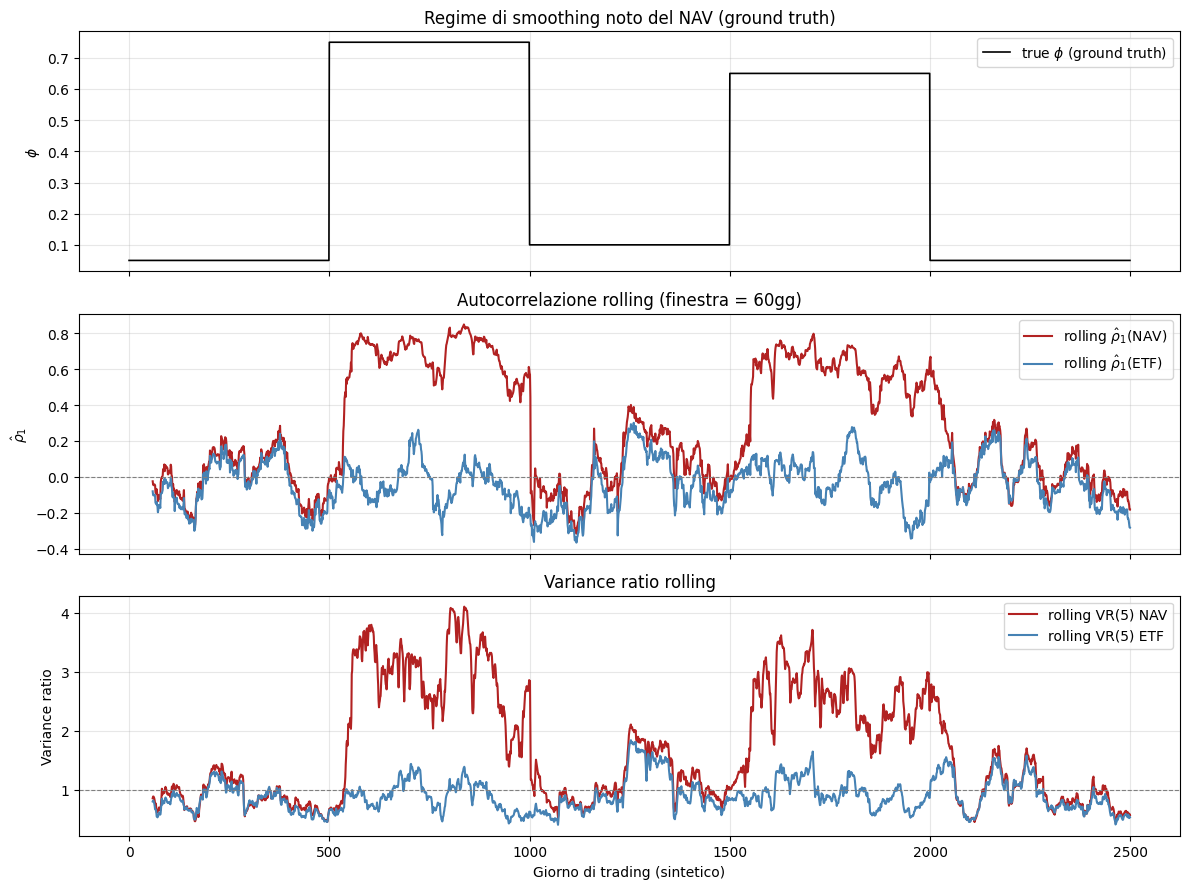

In [5]:
# Build a synthetic path with a known regime schedule: phi switches between
# a "liquid" and a "stale" value at known break points (ground truth for validation).
segment_length = 500
phi_schedule = [0.05, 0.75, 0.10, 0.65, 0.05]  # low, high, low, high, low

true_parts, nav_parts, etf_parts, true_phi_parts = [], [], [], []
for i, phi_seg in enumerate(phi_schedule):
    t_r, n_r, e_r = simulate_smoothed_fund(n=segment_length, phi=phi_seg, seed=RANDOM_SEED + i)
    true_parts.append(t_r)
    nav_parts.append(n_r)
    etf_parts.append(e_r)
    true_phi_parts.append(np.full(segment_length, phi_seg))

sim_nav_r = np.concatenate(nav_parts)
sim_etf_r = np.concatenate(etf_parts)
sim_true_phi = np.concatenate(true_phi_parts)
sim_index = np.arange(len(sim_nav_r))

rho1_nav_roll = rolling_autocorr_lag1(pd.Series(sim_nav_r), ROLL_WINDOW)
rho1_etf_roll = rolling_autocorr_lag1(pd.Series(sim_etf_r), ROLL_WINDOW)
vr_nav_roll = rolling_variance_ratio(pd.Series(sim_nav_r), ROLL_WINDOW, VR_HORIZON)
vr_etf_roll = rolling_variance_ratio(pd.Series(sim_etf_r), ROLL_WINDOW, VR_HORIZON)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(sim_index, sim_true_phi, color="black", lw=1.2, label=r"true $\phi$ (ground truth)")
axes[0].set_ylabel(r"$\phi$")
axes[0].legend(loc="upper right")
axes[0].set_title("Regime di smoothing noto del NAV (ground truth)")

axes[1].plot(rho1_nav_roll, label=r"rolling $\hat\rho_1$(NAV)", color="firebrick")
axes[1].plot(rho1_etf_roll, label=r"rolling $\hat\rho_1$(ETF)", color="steelblue")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_ylabel(r"$\hat\rho_1$")
axes[1].legend(loc="upper right")
axes[1].set_title(f"Autocorrelazione rolling (finestra = {ROLL_WINDOW}gg)")

axes[2].plot(vr_nav_roll, label=f"rolling VR({VR_HORIZON}) NAV", color="firebrick")
axes[2].plot(vr_etf_roll, label=f"rolling VR({VR_HORIZON}) ETF", color="steelblue")
axes[2].axhline(1, color="gray", lw=0.8, ls="--")
axes[2].set_ylabel("Variance ratio")
axes[2].set_xlabel("Giorno di trading (sintetico)")
axes[2].legend(loc="upper right")
axes[2].set_title("Variance ratio rolling")

plt.tight_layout()
plt.savefig("../figures/smoothing_rolling_diagnostics.png", dpi=130, bbox_inches="tight")
plt.show()

> **In parole semplici.** La curva rossa (NAV) sale e scende esattamente
> insieme al regime noto nel pannello sopra; la curva blu (prezzo ETF)
> resta piatta vicino a zero per tutta la simulazione, a prescindere da
> cosa stia facendo il NAV. Se il racconto della Sezione 2 è corretto, è
> proprio questo che ci aspettiamo di vedere — ed è quello che vediamo.

**Un gap grande non è un segnale di allarme.** Vale la pena chiarirlo prima
di passare ai dati reali: quando $\hat\rho_1(NAV)-\hat\rho_1(ETF)$ è grande,
significa che il sottostante è molto stantio (modello 2.1) **e che,
nonostante questo, il prezzo dell'ETF resta pulito** (modello 2.2 intatto) —
la trasformazione di liquidità sta funzionando come dovrebbe, non si sta
rompendo. In questa simulazione il rumore idiosincratico del prezzo ETF
($\eta_t$) ha varianza costante per costruzione: non abbiamo mai simulato
uno scenario in cui il meccanismo si rompe *davvero*. Una rottura genuina si
manifesterebbe in modo diverso — non con $\hat\rho_1(NAV)$ che sale, ma con
$\hat\rho_1(ETF)$ che comincia anch'esso a salire verso quello del NAV (il
modello 2.2 smette di valere, il market maker non riesce più a tenere il
prezzo "fresco"). È il segnale da cercare nei dati reali di un vero
fallimento del meccanismo, non un gap grande di per sé.

## 5. Dati reali: NAV di LQD e HYG (nessuna rete richiesta)

Questa sezione applica lo stimatore del modello 2.1 al NAV reale di LQD e
HYG (già esportato da iShares per il progetto principale) — non serve
l'OHLCV dell'ETF, quindi gira senza rete anche in modalità `DEMO = False`.

L'ipotesi economica: le obbligazioni **high-yield** (HYG) sono tipicamente
meno liquide di quelle **investment-grade** (LQD) — ci aspettiamo quindi che
il NAV di HYG mostri **più** smoothing.

In [6]:
def load_real_nav(path: str) -> pd.Series:
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").set_index("Date")
    nav = df["NAV"].astype(float)
    log_ret = np.log(nav).diff().dropna()
    return log_ret


real_nav_returns = {}
for ticker, path in NAV_CSV.items():
    if Path(path).exists():
        real_nav_returns[ticker] = load_real_nav(path)
        print(f"{ticker}: {len(real_nav_returns[ticker])} daily NAV log-returns "
              f"({real_nav_returns[ticker].index.min().date()} -> {real_nav_returns[ticker].index.max().date()})")
    else:
        print(f"{ticker}: NAV file '{path}' not found - skipping.")

LQD: 6079 daily NAV log-returns (2002-07-23 -> 2026-09-16)
HYG: 4897 daily NAV log-returns (2007-04-05 -> 2026-09-18)


In [7]:
real_summary_rows = []
real_rolling = {}
for ticker, ret in real_nav_returns.items():
    rho1_full = ret.autocorr(lag=1)
    vr_full = rolling_variance_ratio(ret, window=len(ret), q=VR_HORIZON).iloc[-1]
    _, p_lb = ljung_box_test(ret, lags=LB_LAGS)
    roll_rho1 = rolling_autocorr_lag1(ret, ROLL_WINDOW)
    roll_vr = rolling_variance_ratio(ret, ROLL_WINDOW, VR_HORIZON)
    real_rolling[ticker] = pd.DataFrame({"rho1": roll_rho1, "vr": roll_vr})
    real_summary_rows.append({
        "Fondo": ticker,
        "N giorni": len(ret),
        "rho1(NAV), full-sample": round(rho1_full, 4),
        f"VR({VR_HORIZON}), full-sample": round(vr_full, 4),
        "rho1(NAV), media rolling": round(roll_rho1.mean(), 4),
        "Ljung-Box p": "<0.0001" if p_lb < 1e-4 else round(p_lb, 4),
    })

real_summary_df = pd.DataFrame(real_summary_rows)
print(real_summary_df.to_string(index=False))

Fondo  N giorni  rho1(NAV), full-sample  VR(5), full-sample  rho1(NAV), media rolling Ljung-Box p
  LQD      6079                  0.0999              1.2201                    0.0235     <0.0001
  HYG      4897                  0.3409              1.9647                    0.2126     <0.0001


> **In parole semplici.** Se HYG mostra numeri più alti di LQD in questa
> tabella, è evidenza — usando solo i dati NAV, senza guardare il prezzo
> dell'ETF né l'order book delle obbligazioni — che il paniere high-yield è
> più stantio/illiquido di quello investment-grade, coerentemente con
> quello che ci si aspetta economicamente. Il $p$-value di Ljung–Box vicino
> a zero per entrambi i fondi dice che l'autocorrelazione osservata non è un
> artefatto campionario: su migliaia di giorni di dati, è troppo forte per
> essere spiegata dal solo rumore.

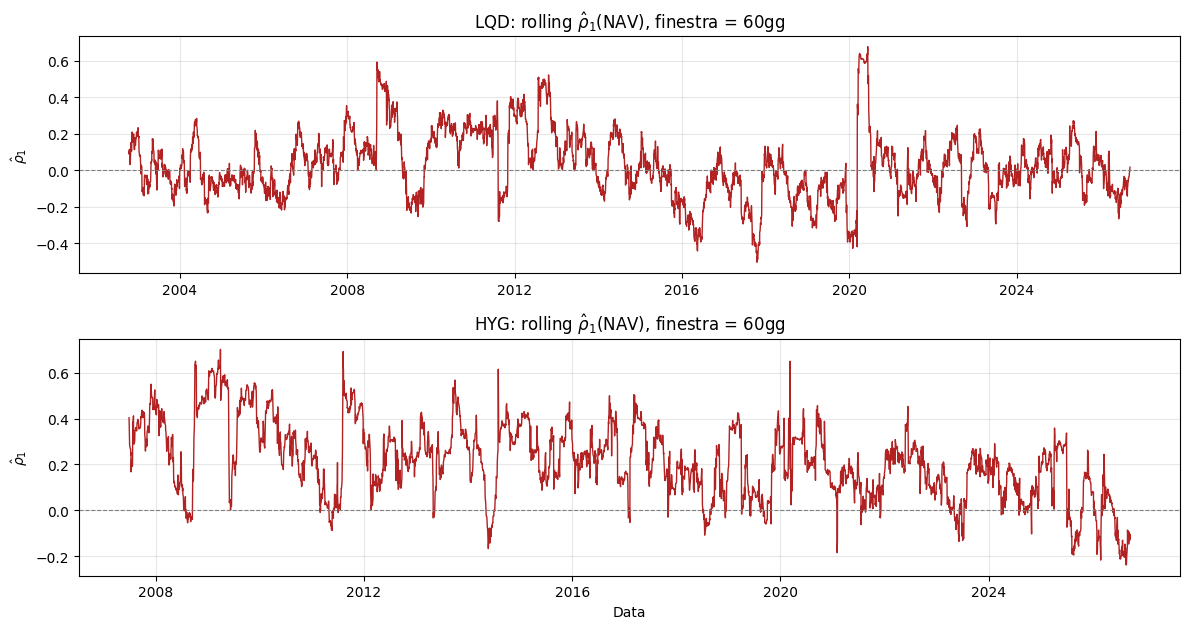

In [8]:
fig, axes = plt.subplots(len(real_rolling), 1, figsize=(12, 3.2 * len(real_rolling)), sharex=False)
if len(real_rolling) == 1:
    axes = [axes]

for ax, (ticker, df_roll) in zip(axes, real_rolling.items()):
    ax.plot(df_roll.index, df_roll["rho1"], color="firebrick", lw=1.0)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"{ticker}: rolling $\\hat\\rho_1$(NAV), finestra = {ROLL_WINDOW}gg")
    ax.set_ylabel(r"$\hat\rho_1$")

axes[-1].set_xlabel("Data")
plt.tight_layout()
plt.savefig("../figures/smoothing_real_nav_rho1.png", dpi=130, bbox_inches="tight")
plt.show()

### 5.1 Perché questi numeri rispondono alla domanda di ricerca

La connessione è diretta: i due modelli sono la traduzione statistica dei
due lati del meccanismo di trasformazione della liquidità, e il gap tra le
loro proprietà è la prova empirica che risponde alla domanda.

Il modello NAV (smoothing di Getmansky-Lo-Makarov) rappresenta cosa succede
se il sottostante è davvero illiquido: i bond del paniere non tradano con
continuità, quindi il NAV calcolato ogni giorno usa prezzi stale/datati per
una parte dei titoli. Questo produce autocorrelazione positiva nei
rendimenti del NAV ($\hat\rho_1 = \hat\phi$), e $\phi$ è di fatto una misura
quantitativa di quanto è "vecchia" l'informazione nel paniere — più il
sottostante è illiquido, più $\phi$ è alto. Il test di Ljung-Box conferma
che questa autocorrelazione non è rumore campionario ma un pattern
statisticamente solido ($p<0.0001$ su LQD e HYG, tabella sopra), cioè
conferma che il sottostante è davvero illiquido, non solo "presunto tale".

Il modello di prezzo ETF ($r^P_t = r^\ast_t + \eta_t$, rumore idiosincratico)
rappresenta invece l'ipotesi che l'ETF, pur avendo quel sottostante, sia
scambiato come un asset liquido: prezzo che si forma in continuo sul mercato
secondario order-driven, senza dipendere da quando ha tradato l'ultimo bond
nel paniere. Se questa ipotesi è vera, $\hat\rho_1$(ETF) dovrebbe essere
statisticamente zero — ed è esattamente quello che si osserva nella
simulazione della Sezione 3 (Ljung-Box mai significativo sull'ETF sintetico),
e riproducibile sui dati reali nella Sezione 6.

**Qui sta la risposta alla domanda di ricerca:** se l'ETF fosse semplicemente
"lo stesso asset" del paniere sottostante, il prezzo dell'ETF dovrebbe
ereditare la stessa autocorrelazione del NAV. Non la eredita. Il gap
$\hat\rho_1(NAV) - \hat\rho_1(ETF) \approx \phi - 0$ è la firma quantitativa
della trasformazione di liquidità: misura quanto il wrapper ETF sta
"scollegando" la liquidità osservata sul mercato secondario dalla liquidità
reale del sottostante.

Il *perché* meccanicistico di questo gap è ciò che l'analisi principale (che
esponi tu) sviluppa: il market maker fa continuous hedging con proxy liquidi
correlati (futures su tassi, indici CDS, altri ETF liquidi) invece di
tradare i singoli bond illiquidi ad ogni quotazione — questo gli permette di
quotare in continuo anche quando il sottostante è fermo. L'AP, tramite
creation/redemption sul mercato primario, agisce solo periodicamente per
riallineare il prezzo dell'ETF al NAV via arbitraggio, senza che ogni trade
in borsa debba toccare il sottostante. Il mercato secondario order-driven fa
il resto: price discovery continuo indipendente dalla frequenza di trading
del paniere.

> **In parole semplici.** I modelli non spiegano il "come" (quello lo fai tu
> con MM/AP/creation-redemption), ma misurano il "quanto" — danno un numero
> a un fenomeno che altrimenti resterebbe solo narrativo, e quel numero (il
> gap di autocorrelazione, statisticamente significativo) è la conferma
> empirica che la trasformazione di liquidità sta effettivamente avvenendo
> nei dati reali di LQD e HYG.

## 6. Estensione a rete: confronto completo NAV-vs-prezzo su dati reali

Il confronto più diretto — $\hat\rho_1(NAV)$ contro $\hat\rho_1(P)$ **per
lo stesso fondo**, esattamente come nella simulazione della Sezione 4 —
richiede anche l'OHLCV di borsa dell'ETF (via `yfinance`), che in questo
ambiente non è raggiungibile in rete. La cella sotto è pronta per essere
eseguita in locale con `DEMO = False`: scarica l'OHLCV, ricalcola i
rendimenti di prezzo, applica esattamente le stesse funzioni
`rolling_autocorr_lag1` e `rolling_variance_ratio` definite (e validate)
sopra.

In [9]:
if not DEMO:
    import yfinance as yf

    real_gap_features = {}
    for ticker in TICKERS:
        if ticker not in real_nav_returns:
            print(f"{ticker}: no NAV data loaded, skipping.")
            continue

        # period="max" is essential here: yf.download() defaults to the last
        # 1 month of data when start/end are omitted, which is far shorter
        # than ROLL_WINDOW (60 days) - the rolling autocorrelation would then
        # be all-NaN and the plot below would come out empty.
        px_raw = yf.download(ticker, period="max", progress=False, auto_adjust=True)["Close"]
        # yfinance >= 1.x returns a MultiIndex-column DataFrame by default even
        # for a single ticker (multi_level_index=True), so ["Close"] can come
        # back as a 1-column DataFrame instead of a Series; pd.Series() on that
        # raises "Data must be 1-dimensional". Squeeze it down defensively so
        # this works across yfinance versions/defaults.
        if isinstance(px_raw, pd.DataFrame):
            px_raw = px_raw.iloc[:, 0]
        px = px_raw.dropna()
        px_ret = np.log(px).diff().dropna()
        px_ret.index = pd.to_datetime(px_ret.index).tz_localize(None)

        nav_ret = real_nav_returns[ticker].copy()
        nav_ret.index = pd.to_datetime(nav_ret.index).tz_localize(None)

        common_idx = px_ret.index.intersection(nav_ret.index)
        px_ret, nav_ret = px_ret.loc[common_idx], nav_ret.loc[common_idx]
        print(f"{ticker}: {len(common_idx)} overlapping trading days "
              f"({common_idx.min().date()} -> {common_idx.max().date()})")

        rho1_nav_roll_r = rolling_autocorr_lag1(nav_ret, ROLL_WINDOW)
        rho1_etf_roll_r = rolling_autocorr_lag1(px_ret, ROLL_WINDOW)
        gap_r = (rho1_nav_roll_r - rho1_etf_roll_r).dropna()

        real_gap_features[ticker] = pd.DataFrame({
            "rho1_nav": rho1_nav_roll_r,
            "rho1_etf": rho1_etf_roll_r,
            "gap": rho1_nav_roll_r - rho1_etf_roll_r,
        }).dropna()

        if real_gap_features[ticker].empty:
            print(f"{ticker}: nessuna riga valida dopo il rolling ({ROLL_WINDOW}gg) - "
                  f"servono almeno {ROLL_WINDOW} giorni di dati sovrapposti tra NAV e "
                  "prezzo ETF. Controllare che yf.download() stia scaricando l'intera "
                  "storia (period='max') e non solo l'ultimo mese.")
            continue

        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(real_gap_features[ticker].index, real_gap_features[ticker]["rho1_nav"],
                label=r"$\hat\rho_1$(NAV)", color="firebrick")
        ax.plot(real_gap_features[ticker].index, real_gap_features[ticker]["rho1_etf"],
                label=r"$\hat\rho_1$(prezzo ETF)", color="steelblue")
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        ax.set_title(f"{ticker}: NAV vs prezzo ETF, autocorrelazione rolling ({ROLL_WINDOW}gg)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"../figures/smoothing_real_gap_{ticker.lower()}.png", dpi=130, bbox_inches="tight")
        plt.show()

    # Cross-fund comparison table, mirroring Section 5's NAV-only version
    if real_gap_features:
        rows = []
        for ticker, df_g in real_gap_features.items():
            rows.append({
                "Fondo": ticker,
                "rho1(NAV) media": round(df_g["rho1_nav"].mean(), 4),
                "rho1(ETF) media": round(df_g["rho1_etf"].mean(), 4),
                "gap medio": round(df_g["gap"].mean(), 4),
            })
        display(pd.DataFrame(rows))
else:
    print("DEMO = True: sezione saltata. Impostare DEMO = False ed eseguire in locale "
          "(richiede 'pip install yfinance' e connessione di rete) per il confronto "
          "NAV-vs-prezzo sui dati reali di mercato.")

DEMO = True: sezione saltata. Impostare DEMO = False ed eseguire in locale (richiede 'pip install yfinance' e connessione di rete) per il confronto NAV-vs-prezzo sui dati reali di mercato.


## 7. Conclusioni

**Sulla domanda di ricerca.** I due modelli fissati nella Sezione 2 non sono
solo un'astrazione statistica: codificano direttamente i due livelli di
mercato dell'analisi principale. Il modello 2.1 (NAV) rappresenta il lato
primario/di valutazione, che eredita l'illiquidità delle obbligazioni sotto
forma di autocorrelazione seriale positiva. Il modello 2.2 (prezzo ETF)
rappresenta il lato secondario/order-driven, dove il continuous hedging del
market maker mantiene il prezzo statisticamente pulito senza bisogno che le
obbligazioni sottostanti si riprezzino. La validazione sintetica (Sezione 3)
conferma che i nostri stimatori distinguono correttamente i due modelli, e
il test di Ljung–Box conferma che quella distinzione è statisticamente
solida, non un artefatto campionario; i dati reali (Sezione 5) confermano
che il NAV di HYG è più stantio di quello di LQD, con significatività
formale, coerentemente con la minore liquidità del credito high-yield.

**Come si collega all'analisi principale.** Il meccanismo di
creation/redemption, studiato nell'analisi principale tramite il
premio/sconto $\pi_t = P_t - NAV_t$, è precisamente ciò che impedisce ai due
processi modellati qui di divergere indefinitamente — ma agisce in modo
discreto e periodico (blocchi di creation unit), non giorno per giorno.
Ecco perché $P_t$ e $NAV_t$ possono avere dinamiche statistiche così diverse
pur restando ancorati nel lungo periodo: l'ancoraggio è garantito
dall'arbitraggio (mercato primario), non dal fatto che i due processi
condividano la stessa "memoria" statistica giorno per giorno (che dipende
invece da mercato secondario e valutazione, mercato primario in senso lato).

**Limiti.** La finestra rolling (60 giorni) è una scelta di design con il
consueto trade-off bias/varianza; il modello di smoothing geometrico è una
parametrizzazione conveniente, non l'unica possibile; il confronto completo
NAV-contro-prezzo su dati reali richiede l'OHLCV dell'ETF (rete), non
eseguito in questo ambiente — la Sezione 5 (solo NAV) resta comunque un test
reale e autosufficiente dell'ipotesi IG-vs-HY; un $\hat\rho_1$ positivo
potrebbe in linea di principio riflettere anche altre fonti di
autocorrelazione oltre allo smoothing, non isolate qui.

**Possibili estensioni.** Un confronto su un terzo segmento di credito (EMB)
per verificare se il gradiente di staleness IG < HY < EM regge; simulare
esplicitamente anche una rottura del modello 2.2 (market maker che smette
di hedgiare in modo continuo), per completare il quadro sintetico con lo
scenario di trasformazione che fallisce davvero; test di Ljung–Box anche
sulle finestre rolling (non solo full-sample) per localizzare nel tempo i
periodi in cui l'autocorrelazione del NAV è statisticamente significativa.